In [108]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from cuda_cqed.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

## Fast Res Driving

In [224]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wb', 5.35e9*2*pi)
sim.add_param('wc', 7.275e9*2*pi, is_excitation=True)
sim.add_param('sqrtkb', np.sqrt(1e6 * 2 * np.pi))
sim.add_param('sqrtkc', np.sqrt(2e6 * 2 * np.pi))
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('g4', 0.01e6 * 2 * np.pi)

sim.add_paramsweep('amplG', 0, 0.3, 51)
sim.add_paramsweep('amplC2', 0, 1.5, 51)
sim.add_param('wG', 10.7e9 * 2 * np.pi)
sim.add_param('wC2', -1.925e9 * 2 * np.pi)
sim.add_param('rampG', 1e-9)
sim.add_param('rampC2', 1e-9)
sim.add_param('startG', 20e-9)
sim.add_param('stopG', 200e-9)
sim.add_param('startC2', 20e-9)
sim.add_param('stopC2', 200e-9)
sim.add_param('phaseG', 0)
sim.add_paramsweep('phaseC2', 0, 2*np.pi, 11)

Gpulse = sim.make_pulse('wG', 'amplG', 'phaseG', 'startG', 'stopG', 'rampG')
C2pulse = sim.make_pulse('wC2', 'amplC2', 'phaseC2', 'startC2', 'stopC2', 'rampC2')

sim.add_EOM('s1', Gpulse)
sim.add_EOM('s2', C2pulse)

sim.add_EOM('b', '-1j*wb*b - 1j*gbc*c*s2 - (sqrtkb**2/2)*b + 1j*g3*conjugate(b)*s1 - 1j*b*g4*abs(b)**2', IC_str='3')
sim.add_EOM('c', '-1j*wc*c - 1j*gbc*b*conjugate(s2) - (sqrtkc**2/2)*c')
sim.set_solve_type('decimate')

sim.specify_time(pts_per_cycle=20, num_cycles=1500, d_factor=10)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


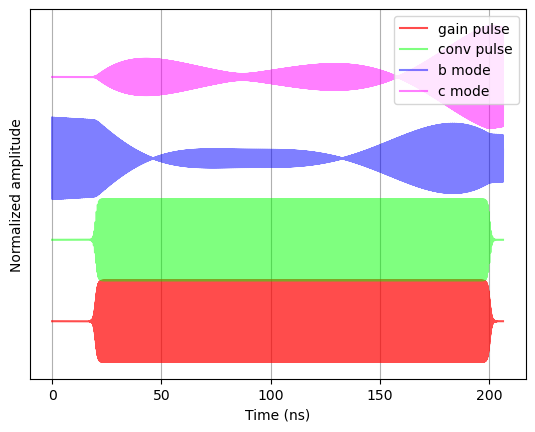

In [225]:
x, tq = sim.quick_trace()

scale = 3

plt.figure(1)
plt.clf()
plt.plot(tq*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='gain pulse')
plt.plot(tq*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='conv pulse')
plt.plot(tq*1e9, x[4,:]/scale+4,color=(0,0,1,0.5),label='b mode')
plt.plot(tq*1e9, x[6,:]/scale+6,color=(1,0,1,0.5),label='c mode')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.yticks([])
plt.grid()
plt.show()

In [226]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 30000/30000 [00:33<00:00, 895.80it/s]


 
...finished GPU solve!


In [229]:
sqrtkb = sim.param_dict_nosweep['sqrtkb']
sqrtkc = sim.param_dict_nosweep['sqrtkc']

bout_I = I[4,:]
bout_Q = I[5,:]

cout_I = I[6,:]
cout_Q = I[7,:]

i = 3

integrated_signal = np.mean(np.abs(cout_I[:,:,i,:] + 1j*cout_Q[:,:,i,:]), axis=-1)

max_snail_disp = np.max(np.abs(bout_I[:,:,i,:] + 1j*bout_Q[:,:,i,:]), axis=-1)

C:\Users\boris\AppData\Local\Temp\ipykernel_56208\580564667.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolor(sim.paramsweep_dict['amplC2'], sim.paramsweep_dict['amplG'], np.log10(integrated_signal))


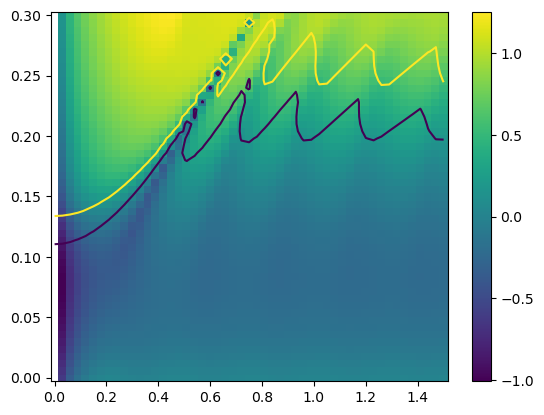

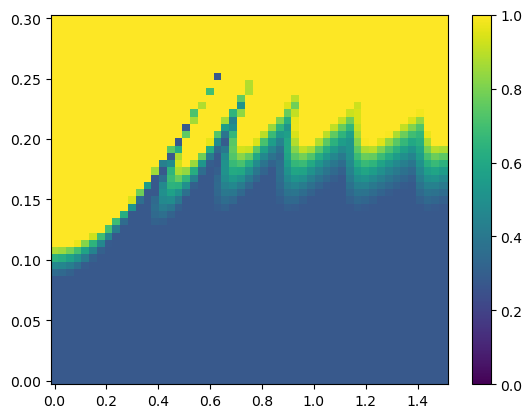

In [232]:
plt.pcolor(sim.paramsweep_dict['amplC2'], sim.paramsweep_dict['amplG'], np.log10(integrated_signal))
plt.colorbar()
plt.contour(sim.paramsweep_dict['amplC2'],sim.paramsweep_dict['amplG'],  max_snail_disp, levels=[1, 3])
plt.show()

plt.pcolor(sim.paramsweep_dict['amplC2'], sim.paramsweep_dict['amplG'], max_snail_disp)
plt.clim([0,1])
plt.colorbar()
plt.show()

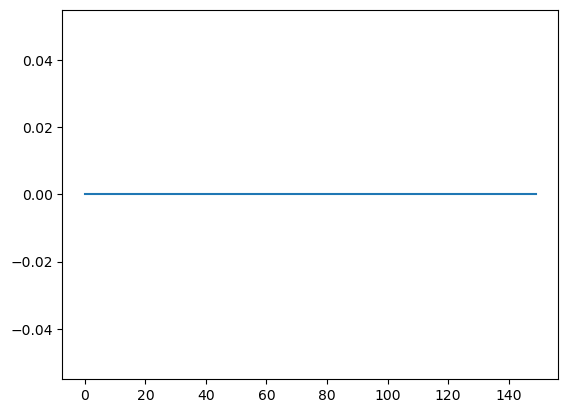

In [223]:
j = 10
k = 0
plt.plot(np.abs(cout_I[j,k,i,:] + 1j*cout_Q[j,k,i,:]))
plt.show()